# Lung Cancer Detection CNN (Xception Transfer Learning)
This notebook implements an end-to-end Deep Learning pipeline using **Transfer Learning with Xception** to classify chest CT scan images into four distinct diagnoses:
- **Normal**
- **Adenocarcinoma**
- **Large Cell Carcinoma**
- **Squamous Cell Carcinoma**

## 1. Environment & Directory Setup
Locate the dataset path, establish the workspace root, and initialize a dedicated `models/` directory for saving trained weights and tracking experiment metrics.

In [5]:
# Verify local environment and dataset paths
import os
from pathlib import Path

# Auto-detect project folder (works whether notebook is opened from root or Lung-cancer-model-train)
cwd = Path.cwd()
if (cwd / "dataset").exists():
    BASE_DIR = cwd
elif (cwd / "Lung-cancer-model-train" / "dataset").exists():
    BASE_DIR = cwd / "Lung-cancer-model-train"
else:
    BASE_DIR = cwd

DATASET_DIR = BASE_DIR / "dataset"
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_TRACKER_PATH = MODELS_DIR / "model_tracker.md"

# print(f"Active Project Directory: {BASE_DIR}")
# print(f"Dataset Directory: {DATASET_DIR} (Found: {DATASET_DIR.exists()})")
# print(f"Dedicated Models Directory: {MODELS_DIR}")
# print(f"Model Tracker: {MODEL_TRACKER_PATH} (Found: {MODEL_TRACKER_PATH.exists()})")


## 2. Dataset Partitions & Class Folders
Define paths for train, validation, and test partitions, as well as subdirectory paths corresponding to each lung cancer subtype.

In [6]:
# Define paths to the training, validation, and test datasets
train_folder = str(DATASET_DIR / "train")
validate_folder = str(DATASET_DIR / "valid")
test_folder = str(DATASET_DIR / "test")

# Define paths to the specific classes within the dataset
normal_folder = "/normal"
adenocarcinoma_folder = "/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib"
large_cell_carcinoma_folder = "/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa"
squamous_cell_carcinoma_folder = "/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"


## 3. Libraries & Image Data Preprocessing
Import TensorFlow, Keras, scikit-learn, and visualization packages. Initialize `ImageDataGenerator` pipelines with pixel normalization (`1/255.0`), image resizing to (350, 350), and data augmentation (horizontal flips for training).

In [7]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

from keras.applications import Xception
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.layers import Dense, Dropout, SpatialDropout2D, Activation, Lambda, Flatten, LSTM
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.models import Sequential
from keras.optimizers import Adam, RMSprop
from keras import utils
# Access preprocessing utilities via tf.keras to avoid static import resolution issues in TF 2.16+
image = tf.keras.preprocessing.image
ImageDataGenerator = tf.keras.preprocessing.image.ImageDataGenerator
print("Libraries Imported")
# Set the image size for resizing
IMAGE_SIZE = (350, 350)
# Initialize the image data generators for training and testing
print("Reading training images from:", train_folder)
print("Reading validation images from:", validate_folder)
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)
# Define the batch size for training
batch_size = 8
# Create the training data generator
train_generator = train_datagen.flow_from_directory(
    train_folder,
    target_size=IMAGE_SIZE,
    batch_size=batch_size,
    color_mode="rgb",
    class_mode='categorical'
)
# Create the validation data generator
validation_generator = test_datagen.flow_from_directory(
    validate_folder,
    target_size=IMAGE_SIZE,
    batch_size=batch_size,
    color_mode="rgb",
    class_mode='categorical'
)


Libraries Imported
Reading training images from: d:\Coding_local\Lung-cancer-detection-CNN\Lung-cancer-model-train\dataset\train
Reading validation images from: d:\Coding_local\Lung-cancer-detection-CNN\Lung-cancer-model-train\dataset\valid
Found 613 images belonging to 4 classes.


Found 72 images belonging to 4 classes.


## 4. Training Callbacks Configuration
Configure callbacks to monitor loss, decay learning rate on plateaus, stop early to avoid overfitting, and save the best checkpoint weights into the dedicated `models/` directory.

In [66]:
# Set up callbacks for learning rate reduction, early stopping, and model checkpointing
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

BEST_MODEL_WEIGHTS = MODELS_DIR / "best_model.hdf5"

learning_rate_reduction = ReduceLROnPlateau(monitor='loss', patience=5, verbose=2, factor=0.5, min_lr=0.000001)
early_stops = EarlyStopping(monitor='loss', min_delta=0, patience=6, verbose=2, mode='auto')
checkpointer = ModelCheckpoint(filepath=str(BEST_MODEL_WEIGHTS), verbose=2, save_best_only=True, save_weights_only=True)


## 5. Model Architecture (Transfer Learning)
Instantiate a pre-trained **Xception** base model with frozen ImageNet weights. Attach a `GlobalAveragePooling2D` layer and a 4-unit `Dense` layer with Softmax activation for categorical classification.

In [67]:
# Define the number of output classes
OUTPUT_SIZE = 4

# Load a pre-trained model (Xception) without the top layers and freeze its weights
pretrained_model = Xception(weights='imagenet', include_top=False, input_shape=[*IMAGE_SIZE, 3])
pretrained_model.trainable = False

# Create a new model with the pre-trained base and additional layers for classification
model = Sequential()
model.add(pretrained_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(OUTPUT_SIZE, activation='softmax'))

print("Pretrained model used:")
pretrained_model.summary()

print("Final model created:")
model.summary()

# Compile the model with an optimizer, loss function, and evaluation metric
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


83683744/83683744 [==============================] - 3s 0us/step
Pretrained model used:
Model: "xception"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 350, 350, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 174, 174, 32)         864       ['input_3[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 174, 174, 32)         128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 bl

## 6. Model Training & Validation
Train the model on the data generator stream. Training runs for up to 50 epochs (25 steps per epoch), with automatic early stopping and learning rate adaptation.

In [68]:
# Train the model with the training and validation data generators
history = model.fit(
    train_generator,
    steps_per_epoch=25,
    epochs=50,
    callbacks=[learning_rate_reduction, early_stops, checkpointer],
    validation_data=validation_generator,
    validation_steps=20
)

print("Final training accuracy =", history.history['accuracy'][-1])
print("Final testing accuracy =", history.history['val_accuracy'][-1])


Epoch 1/50
25/25 [==============================] - ETA: 0s - loss: 1.2235 - accuracy: 0.4467
Epoch 1: val_loss improved from inf to 1.08683, saving model to best_model.hdf5
25/25 [==============================] - 201s 8s/step - loss: 1.2235 - accuracy: 0.4467 - val_loss: 1.0868 - val_accuracy: 0.5437 - lr: 0.0010
Epoch 2/50
25/25 [==============================] - ETA: 0s - loss: 1.0109 - accuracy: 0.5400
Epoch 2: val_loss improved from 1.08683 to 1.01950, saving model to best_model.hdf5
25/25 [==============================] - 251s 10s/step - loss: 1.0109 - accuracy: 0.5400 - val_loss: 1.0195 - val_accuracy: 0.5250 - lr: 0.0010
Epoch 3/50
25/25 [==============================] - ETA: 0s - loss: 0.8993 - accuracy: 0.6200
Epoch 3: val_loss improved from 1.01950 to 0.86878, saving model to best_model.hdf5
25/25 [==============================] - 252s 10s/step - loss: 0.8993 - accuracy: 0.6200 - val_loss: 0.8688 - val_accuracy: 0.5938 - lr: 0.0010
Epoch 4/50
25/25 [=====================

## 7. Training History & Performance Curves
Visualize training vs. validation loss and accuracy curves across training epochs to diagnose convergence and generalization.

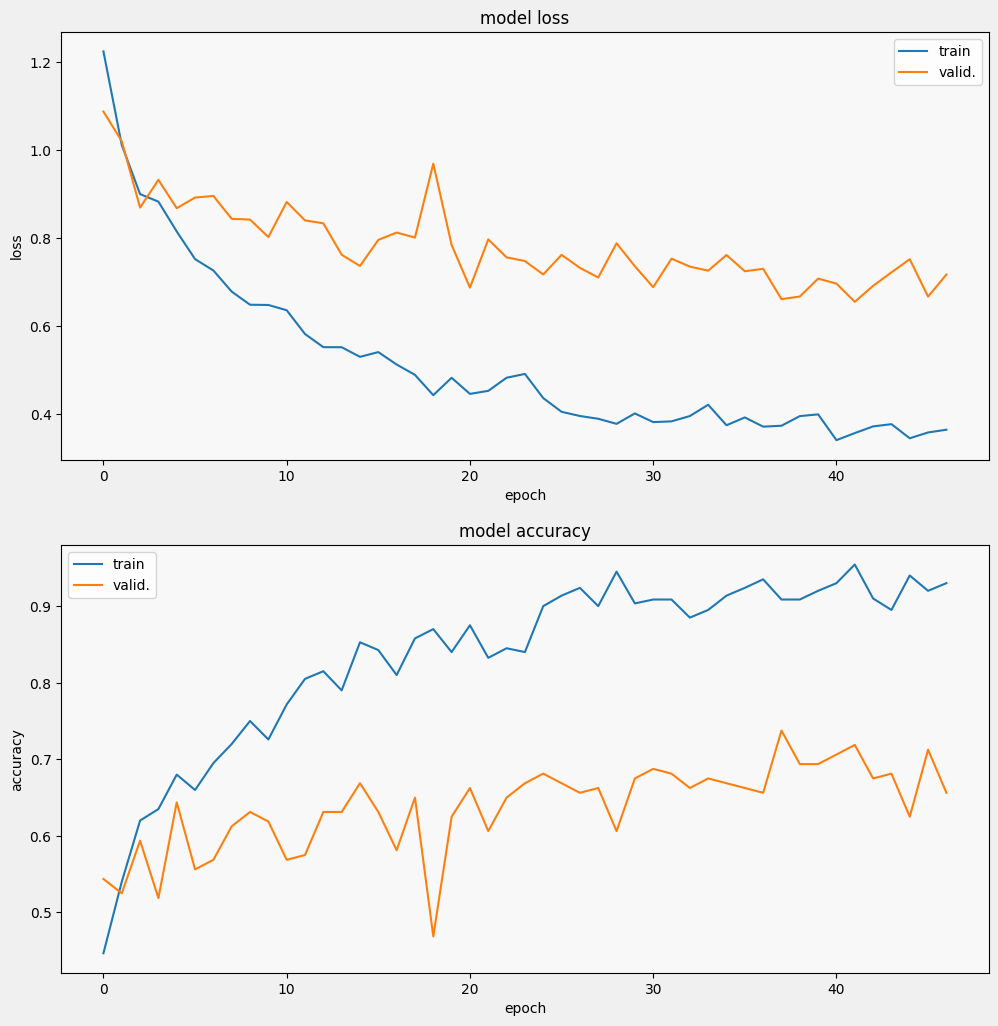

In [69]:
# Function to display training curves for loss and accuracy
def display_training_curves(training, validation, title, subplot):
    if subplot % 10 == 1:
        plt.subplots(figsize=(10, 10), facecolor='#F0F0F0')
        plt.tight_layout()
    ax = plt.subplot(subplot)
    ax.set_facecolor('#F8F8F8')
    ax.plot(training)
    ax.plot(validation)
    ax.set_title('model ' + title)
    ax.set_ylabel(title)
    ax.set_xlabel('epoch')
    ax.legend(['train', 'valid.'])

# Display training curves for loss and accuracy
display_training_curves(history.history['loss'], history.history['val_loss'], 'loss', 211)
display_training_curves(history.history['accuracy'], history.history['val_accuracy'], 'accuracy', 212)


## 8. Save Model & Update Model Tracker (.md)
Save the complete trained model in HDF5 (`.h5`) format to the dedicated `models/` folder, and automatically log the training and validation accuracy metrics to `model_tracker.md`.

In [71]:
# Save the trained model to the dedicated models directory
saved_model_path = str(MODELS_DIR / 'trained_lung_cancer_model.h5')
model.save(saved_model_path)
print(f"Model saved to: {saved_model_path}")

# Update minimal model tracker markdown file
import datetime
today = datetime.date.today().isoformat()
train_acc = history.history['accuracy'][-1]
val_acc = history.history.get('val_accuracy', [None])[-1]
val_loss = history.history.get('val_loss', [None])[-1]
epochs_run = len(history.history['loss'])

val_loss_str = f"{val_loss:.4f}" if val_loss is not None else "N/A"
val_acc_str = f"{val_acc*100:.2f}%" if val_acc is not None else "N/A"

log_entry = (
    f"| {today} | `{BEST_MODEL_WEIGHTS.name}` | Xception + GAP + Dense({OUTPUT_SIZE}) | "
    f"{epochs_run} / 50 | {batch_size} | {train_acc*100:.2f}% | {val_acc_str} | "
    f"{val_loss_str} | Notebook training run |\n"
)

if MODEL_TRACKER_PATH.exists():
    with open(MODEL_TRACKER_PATH, "a", encoding="utf-8") as f:
        f.write(log_entry)
    print(f"Updated model tracker at: {MODEL_TRACKER_PATH}")


## 9. Inference & Sample Predictions
Define preprocessing helpers and evaluate model predictions on real CT scan samples from each category.
If needed, pre-trained weights from `models/best_model.hdf5` can be loaded directly for evaluation.

### 9.1 Sample Prediction: Squamous Cell Carcinoma

In [77]:
# Helper function to load and preprocess an image for prediction
import glob
# Access preprocessing utilities via tf.keras to avoid static import resolution issues in TF 2.16+
image = tf.keras.preprocessing.image
import numpy as np

# Ensure best weights are loaded if available
if BEST_MODEL_WEIGHTS.exists():
    try:
        model.load_weights(str(BEST_MODEL_WEIGHTS))
        print(f"Loaded best model weights from: {BEST_MODEL_WEIGHTS}")
    except Exception as e:
        print(f"Note: using in-memory model state ({e})")

def load_and_preprocess_image(img_path, target_size):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Rescale the image like the training images
    return img_array

def get_sample_image(folder_path):
    for ext in ('*.png', '*.jpg', '*.jpeg'):
        found = glob.glob(os.path.join(folder_path, ext))
        if found:
            return found[0]
    return None

# Predict sample for: Squamous Cell Carcinoma
sample_dir = validate_folder + squamous_cell_carcinoma_folder
img_path = get_sample_image(sample_dir)

if img_path:
    img = load_and_preprocess_image(img_path, IMAGE_SIZE)
    predictions = model.predict(img)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100
    class_names = list(train_generator.class_indices.keys())
    print(f"Sample: {img_path}")
    print(f"Predicted Class: {class_names[predicted_class]} ({confidence:.2f}% confidence)")


### 9.2 Sample Prediction: Adenocarcinoma

In [78]:
# Predict sample for: Adenocarcinoma
sample_dir = validate_folder + adenocarcinoma_folder
img_path = get_sample_image(sample_dir)

if img_path:
    img = load_and_preprocess_image(img_path, IMAGE_SIZE)
    predictions = model.predict(img)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100
    class_labels = list(train_generator.class_indices.keys())
    predicted_label = class_labels[predicted_class]
    
    print(f"Image: {img_path}")
    print(f"Predicted class: {predicted_label} ({confidence:.2f}%)")
    
    plt.imshow(image.load_img(img_path, target_size=IMAGE_SIZE))
    plt.title(f"Predicted: {predicted_label} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()
else:
    print(f"No sample image found in {sample_dir}")


### 9.3 Sample Prediction: Large Cell Carcinoma

In [79]:
# Predict sample for: Large Cell Carcinoma
sample_dir = validate_folder + large_cell_carcinoma_folder
img_path = get_sample_image(sample_dir)

if img_path:
    img = load_and_preprocess_image(img_path, IMAGE_SIZE)
    predictions = model.predict(img)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100
    class_labels = list(train_generator.class_indices.keys())
    predicted_label = class_labels[predicted_class]
    
    print(f"Image: {img_path}")
    print(f"Predicted class: {predicted_label} ({confidence:.2f}%)")
    
    plt.imshow(image.load_img(img_path, target_size=IMAGE_SIZE))
    plt.title(f"Predicted: {predicted_label} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()
else:
    print(f"No sample image found in {sample_dir}")


### 9.4 Sample Prediction: Normal (Healthy)

In [80]:
# Predict sample for: Normal
sample_dir = validate_folder + normal_folder
img_path = get_sample_image(sample_dir)

if img_path:
    img = load_and_preprocess_image(img_path, IMAGE_SIZE)
    predictions = model.predict(img)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100
    class_labels = list(train_generator.class_indices.keys())
    predicted_label = class_labels[predicted_class]
    
    print(f"Image: {img_path}")
    print(f"Predicted class: {predicted_label} ({confidence:.2f}%)")
    
    plt.imshow(image.load_img(img_path, target_size=IMAGE_SIZE))
    plt.title(f"Predicted: {predicted_label} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()
else:
    print(f"No sample image found in {sample_dir}")
